# 🫀 ECG ResNet1D — Clasificación Multietiqueta (v3 · CPU · modelo independiente)
## TFM · Sistema de Apoyo a la Decisión Clínica Multimodal · Módulo de ECG
### Universidad de Salamanca · Máster en Análisis Avanzado de Datos Multivariantes y Big Data

---

## 🎯 Qué es este notebook

Modelo **independiente** de clasificación a partir de **electrocardiograma (ECG, 12 derivaciones)**
para las 6 etiquetas `Atelectasis, Cardiomegaly, Edema, Lung Opacity, No Finding, Pleural Effusion`.
Es autónomo: entrena, valida y evalúa **por sí mismo**, sin ninguna fusión con otras modalidades.

El ECG aporta señal **complementaria**, sobre todo en las patologías cardíacas (**Cardiomegaly,
Edema, Pleural Effusion**) según el EDA; para Atelectasis/Lung Opacity la señal es menor.

## 🩺 Tratamiento de No Finding (negativos derivados por exclusividad)

- Si `No Finding == 1` → las 5 patologías = **0** (negativo derivado).
- Si alguna patología `== 1` → `No Finding = **0**`.

Solo rellena **NaN**; nunca pisa valores explícitos ni inciertos. Resuelve que Atelectasis,
Lung Opacity (casi sin negativos) y No Finding (sin negativos) sean entrenables.

## 🛡️ El masking de NaN y −1 se mantiene intacto

| Valor original | label / mask | ¿Entra en la loss? |
|---|---|---|
| `1` | 1 / 1 | Sí |
| `0` | 0 / 1 | Sí |
| `-1` (incierto) | según `uncertainty_policy` / 1 | Sí |
| `NaN` cubierto por exclusividad | 0 / 1 → negativo derivado | **Sí (nuevo)** |
| `NaN` no cubierto | 0 / 0 | **No — sigue enmascarado** |

## 📡 Señal y modelo

- ECG `(N,1,5000,12)` → `(12, 5000)` (12 derivaciones como canales) → submuestreo a ~100 Hz → z-score por derivación.
- **ResNet1D compacto entrenado desde cero** (no hay backbone preentrenado plug-and-play fiable para ECG 1D en CPU). Las 12 derivaciones se tratan como **canales de entrada** de la CNN 1D.

## 🔬 Flujo (modelo independiente)

1. Preprocesado de la señal (cacheado).
2. **Optuna (TPE)** para hiperparámetros (split interno).
3. **K-fold CV** → estimación honesta de rendimiento (media ± desv.).
4. **Modelo final** en todo el train; val para early stopping, umbrales y calibración.
5. **Evaluación única en test** + calibración isotónica.

## 📊 Salidas (ricas)

Tabla de métricas por etiqueta (AUC, AP, F1, sensibilidad, especificidad) · **matrices de confusión** ·
**curvas ROC** · **Precisión-Recall** · **calibración** · **curvas de entrenamiento** · AUC por etiqueta.
`summary_v3.json`, `metrics_per_label_v3.csv`, checkpoint y figuras PNG.

## ⏱️ Coste (i5-1135G7, 4 núcleos, sin GPU → CPU)

El backbone se entrena (no hay atajo de embeddings cacheados). Con señal submuestreada y red compacta,
≈ **1.5–2.5 h**. Ajusta `ECG_LEN`, `OPTUNA_TRIALS`, `K_FOLDS`, `FINAL_EPOCHS`; `FAST_MODE=True` para prueba.


In [1]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 1 · INSTALACIÓN DE DEPENDENCIAS                                       ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import subprocess, sys
for pkg in ["optuna", "scikit-learn", "pandas", "numpy", "matplotlib", "seaborn", "tqdm"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=True)
print("Dependencias instaladas.")


Dependencias instaladas.


In [2]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 2 · IMPORTS, SEMILLAS, HILOS DE CPU Y DISPOSITIVO                     ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import os, gc, json, time, copy, random, warnings
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import KFold
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.isotonic import IsotonicRegression
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING); warnings.filterwarnings("ignore")
SEED = 42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
N_CORES = 4; torch.set_num_threads(N_CORES)
os.environ["OMP_NUM_THREADS"] = str(N_CORES); os.environ["MKL_NUM_THREADS"] = str(N_CORES)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} · Dispositivo {DEVICE} · Hilos {torch.get_num_threads()}")


c:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.8.0+cpu · Dispositivo cpu · Hilos 4


In [3]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 3 · RUTAS, ETIQUETAS Y CONSTANTES                                     ║
# ╚══════════════════════════════════════════════════════════════════════════╝
BASE = Path(r"C:\TFM\1.Opción - Symile Mimic\symile-mimic-a-multimodal-clinical-dataset-of-chest-x-rays-electrocardiograms-and-blood-labs-from-mimic-iv-1.0.0")
CSV_DIR = BASE / "data_csv" / "clean"
TRAIN_CSV, VAL_CSV, TEST_CSV = CSV_DIR/"train_clean.csv", CSV_DIR/"val_clean.csv", CSV_DIR/"test_clean.csv"
NPY = BASE / "data_npy"
ECG_TRAIN_NPY, ECG_VAL_NPY, ECG_TEST_NPY = NPY/"train"/"ecg_train.npy", NPY/"val"/"ecg_val.npy", NPY/"test"/"ecg_test.npy"
HADM_TRAIN_NPY, HADM_VAL_NPY, HADM_TEST_NPY = NPY/"train"/"hadm_id_train.npy", NPY/"val"/"hadm_id_val.npy", NPY/"test"/"hadm_id_test.npy"

OUTPUT_DIR = Path("outputs_ecg_resnet1d_v3"); OUTPUT_DIR.mkdir(exist_ok=True)
PREP_DIR = OUTPUT_DIR / "prep"; PREP_DIR.mkdir(exist_ok=True)
FIG_DIR = OUTPUT_DIR / "figuras"; FIG_DIR.mkdir(exist_ok=True)

LABELS = ["Atelectasis", "Cardiomegaly", "Edema", "Lung Opacity", "No Finding", "Pleural Effusion"]
N_LABELS = len(LABELS); NO_FINDING = "No Finding"
PATHOLOGY_LABELS = [l for l in LABELS if l != NO_FINDING]
CORE_LABELS = ["Cardiomegaly", "Edema", "Pleural Effusion"]

N_LEADS, ECG_RAW_LEN, ECG_LEN = 12, 5000, 1000
DERIVE_NEGATIVES_FROM_EXCLUSIVITY = True

GENDER_MAP    = {0: 0, 1: 1, "0": 0, "1": 1, "M": 1, "F": 0}
RACE_MAP      = {"UNKNOWN": 0, "WHITE": 1, "BLACK": 2, "ASIAN": 3, "HISPANIC_LATINO": 4, "OTHER_KNOWN": 0}
ADMISSION_MAP = {"SCHEDULED": 0, "EMERGENCY": 1, "OBSERVATION": 2, "URGENT": 3}
ADM_LOC_MAP   = {"EMERGENCY_ROOM": 0, "REFERRAL": 1, "TRANSFER": 2, "INTRA_HOSPITAL": 3}
RACE_ONEHOT   = 5
META_DIM = 1 + 1 + RACE_ONEHOT + len(ADMISSION_MAP) + len(ADM_LOC_MAP) + 1   # = 16

FAST_MODE = False
OPTUNA_TRIALS, TUNE_SUBSAMPLE, TUNE_EPOCHS, TUNE_PATIENCE = 8, 0.6, 6, 3
K_FOLDS, FINAL_EPOCHS, FINAL_PATIENCE = 3, 18, 4
BATCH, BASE_WIDTH = 64, 32
if FAST_MODE:
    OPTUNA_TRIALS, TUNE_EPOCHS, K_FOLDS, FINAL_EPOCHS = 3, 3, 2, 5
print(f"ECG {N_LEADS}x{ECG_RAW_LEN}->{ECG_LEN} · META_DIM={META_DIM} · trials={OPTUNA_TRIALS} K={K_FOLDS} FAST={FAST_MODE}")


ECG 12x5000->1000 · META_DIM=16 · trials=8 K=3 FAST=False


In [4]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 4 · CARGA Y ALINEACIÓN CSV <-> NPY (join por hadm_id)                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def load_split(csv_path, ecg_npy_path, hadm_npy_path, name):
    df = pd.read_csv(csv_path, sep=";")
    hadm = np.load(hadm_npy_path, allow_pickle=True); h2i = {int(h): i for i, h in enumerate(hadm)}
    df["_npy_idx"] = df["hadm_id"].map(lambda h: h2i.get(int(h), -1))
    n0 = len(df); df = df[df["_npy_idx"] >= 0].reset_index(drop=True)
    ecg = np.load(ecg_npy_path, mmap_mode="r")
    print(f"{name:5s}: CSV={n0:,} con ECG={len(df):,} (descartadas {n0-len(df)}) · ECG {ecg.shape}")
    return df, ecg
df_train, ecg_train = load_split(TRAIN_CSV, ECG_TRAIN_NPY, HADM_TRAIN_NPY, "train")
df_val,   ecg_val   = load_split(VAL_CSV,   ECG_VAL_NPY,   HADM_VAL_NPY,   "val")
df_test,  ecg_test  = load_split(TEST_CSV,  ECG_TEST_NPY,  HADM_TEST_NPY,  "test")


train: CSV=10,000 con ECG=10,000 (descartadas 0) · ECG (10000, 1, 5000, 12)
val  : CSV=750 con ECG=750 (descartadas 0) · ECG (750, 1, 5000, 12)
test : CSV=464 con ECG=464 (descartadas 0) · ECG (4640, 1, 5000, 12)


In [5]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 5 · OBJETIVOS: MASKING + NEGATIVOS DERIVADOS                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def build_targets(df, uncertainty_policy="zeros", derive=DERIVE_NEGATIVES_FROM_EXCLUSIVITY, verbose=False):
    raw = df[LABELS].to_numpy(dtype=float); N = raw.shape[0]
    labels = np.zeros((N, N_LABELS), dtype=np.float32); mask = np.zeros((N, N_LABELS), dtype=np.float32)
    mask[~np.isnan(raw)] = 1.0; labels[raw == 1] = 1.0
    unc = (raw == -1); labels[unc] = 1.0 if uncertainty_policy == "ones" else 0.0
    nf = LABELS.index(NO_FINDING); path_cols = [j for j in range(N_LABELS) if j != nf]
    n_dp = n_dn = n_c = 0
    if derive:
        nf_pos = (raw[:, nf] == 1)
        for j in path_cols:
            fill = nf_pos & np.isnan(raw[:, j]); labels[fill, j] = 0.0; mask[fill, j] = 1.0; n_dp += int(fill.sum())
        n_c = int((nf_pos[:, None] & (raw[:, path_cols] == 1)).sum())
        anyp = (raw[:, path_cols] == 1).any(axis=1)
        fnf = anyp & np.isnan(raw[:, nf]); labels[fnf, nf] = 0.0; mask[fnf, nf] = 1.0; n_dn = int(fnf.sum())
    if verbose: print(f"   Neg. derivados patologías={n_dp:,} · No Finding={n_dn:,} · contradicciones={n_c:,}")
    return labels, mask
print("== Balance efectivo 'train' =="); _y, _m = build_targets(df_train, "zeros", verbose=True)
for j, lbl in enumerate(LABELS):
    sel = _m[:, j] == 1
    print(f"   {lbl:18s} pos={int((_y[sel,j]==1).sum()):5d} neg={int((_y[sel,j]==0).sum()):5d} "
          f"enmascarados={int((_m[:,j]==0).sum()):5d}")


== Balance efectivo 'train' ==
   Neg. derivados patologías=6,091 · No Finding=7,691 · contradicciones=0
   Atelectasis        pos= 2867 neg= 2052 enmascarados= 5081
   Cardiomegaly       pos= 3346 neg= 2495 enmascarados= 4159
   Edema              pos= 2067 neg= 3735 enmascarados= 4198
   Lung Opacity       pos= 3108 neg= 1733 enmascarados= 5159
   No Finding         pos= 1368 neg= 7691 enmascarados=  941
   Pleural Effusion   pos= 3618 neg= 3194 enmascarados= 3188


In [6]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 6 · METADATOS CLÍNICOS (16 dims)                                      ║
# ╚══════════════════════════════════════════════════════════════════════════╝
AGE_MIN, AGE_MAX = float(df_train["age"].min()), float(df_train["age"].max())
HRS_MIN, HRS_MAX = float(df_train["hours_adm_to_cxr"].min()), float(df_train["hours_adm_to_cxr"].max())
def build_metadata(df):
    # edad, sexo, raza(5), tipo de ingreso(4), lugar de ingreso(4), horas(1).
    N = len(df); M = np.zeros((N, META_DIM), dtype=np.float32)
    for i, (_, row) in enumerate(df.iterrows()):
        off = 0
        M[i, off] = (float(row.get("age", AGE_MIN)) - AGE_MIN) / (AGE_MAX - AGE_MIN + 1e-8); off += 1
        M[i, off] = float(GENDER_MAP.get(row.get("gender", 0), 0)); off += 1
        M[i, off + RACE_MAP.get(str(row.get("race", "UNKNOWN")).upper(), 0)] = 1.0; off += RACE_ONEHOT
        M[i, off + ADMISSION_MAP.get(str(row.get("admission_type", "EMERGENCY")).upper(), 1)] = 1.0; off += len(ADMISSION_MAP)
        M[i, off + ADM_LOC_MAP.get(str(row.get("admission_location", "EMERGENCY_ROOM")).upper(), 0)] = 1.0; off += len(ADM_LOC_MAP)
        M[i, off] = (float(row.get("hours_adm_to_cxr", HRS_MIN)) - HRS_MIN) / (HRS_MAX - HRS_MIN + 1e-8); off += 1
    return M
meta_train, meta_val, meta_test = build_metadata(df_train), build_metadata(df_val), build_metadata(df_test)
print(f"Metadatos: train={meta_train.shape} val={meta_val.shape} test={meta_test.shape}")


Metadatos: train=(10000, 16) val=(750, 16) test=(464, 16)


In [15]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 7 · PREPROCESADO DE LA SEÑAL ECG (submuestreo + z-score por deriv.)   ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def preprocess_ecg(ecg_npy, name):
    cache = PREP_DIR / f"ecg_{name}_{ECG_LEN}.npy"
    if cache.exists(): X = np.load(cache); print(f"   {name}: caché {X.shape}"); return X
    N = ecg_npy.shape[0]; factor = ECG_RAW_LEN // ECG_LEN
    X = np.empty((N, N_LEADS, ECG_LEN), dtype=np.float32)
    for i in tqdm(range(N), desc=f"prep {name}", leave=False):
        a = np.asarray(ecg_npy[i], dtype=np.float32).reshape(ECG_RAW_LEN, N_LEADS).T
        a = a[:, :factor*ECG_LEN].reshape(N_LEADS, ECG_LEN, factor).mean(axis=2)
        mu = a.mean(axis=1, keepdims=True); sd = a.std(axis=1, keepdims=True); X[i] = (a - mu) / (sd + 1e-6)
    cache.parent.mkdir(parents=True, exist_ok=True)
    np.save(cache, X); print(f"   {name}: calculado {X.shape}"); return X

print("Preprocesando ECG...")
print("Verificando alineación splits:")
print(f"   train: ecg={ecg_train.shape[0]:,}  csv={len(df_train):,}  {'✓' if ecg_train.shape[0]==len(df_train) else '✗ desalineado'}")
print(f"   val  : ecg={ecg_val.shape[0]:,}  csv={len(df_val):,}  {'✓' if ecg_val.shape[0]==len(df_val) else '✗ desalineado'}")
print(f"   test : ecg={ecg_test.shape[0]:,}  csv={len(df_test):,}  {'✓' if ecg_test.shape[0]==len(df_test) else '✗ desalineado (10:1 retrieval → se filtra por _npy_idx)'}")

# Train y val: alineados 1:1, se usan directamente
X_train = preprocess_ecg(ecg_train, "train")
X_val   = preprocess_ecg(ecg_val,   "val")

# Test: 4640 ECGs (464 queries × 10 candidatos retrieval) → seleccionar solo los 464 correctos
X_test_full = preprocess_ecg(ecg_test, "test")
X_test = X_test_full[df_test["_npy_idx"].to_numpy()]

print(f"\nShapes finales alineados con CSV y etiquetas:")
print(f"   X_train={X_train.shape}  y_train será ({len(df_train)}, {len(LABELS)})")
print(f"   X_val  ={X_val.shape}  y_val   será ({len(df_val)}, {len(LABELS)})")
print(f"   X_test ={X_test.shape}  y_test  será ({len(df_test)}, {len(LABELS)})")
assert X_test.shape[0] == len(df_test), f"ERROR: X_test {X_test.shape[0]} != df_test {len(df_test)}"
print("✓ Alineación test correcta.")

Preprocesando ECG...
Verificando alineación splits:
   train: ecg=10,000  csv=10,000  ✓
   val  : ecg=750  csv=750  ✓
   test : ecg=4,640  csv=464  ✗ desalineado (10:1 retrieval → se filtra por _npy_idx)
   train: caché (10000, 12, 1000)
   val: caché (750, 12, 1000)


   test: calculado (4640, 12, 1000)

Shapes finales alineados con CSV y etiquetas:
   X_train=(10000, 12, 1000)  y_train será (10000, 6)
   X_val  =(750, 12, 1000)  y_val   será (750, 6)
   X_test =(464, 12, 1000)  y_test  será (464, 6)
✓ Alineación test correcta.


In [8]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 8 · MODELO ResNet1D COMPACTO + CABEZA                                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝
class BasicBlock1d(nn.Module):
    def __init__(self, cin, cout, stride=1, k=7, dropout=0.0):
        super().__init__(); pad = k//2
        self.conv1 = nn.Conv1d(cin, cout, k, stride, pad, bias=False); self.bn1 = nn.BatchNorm1d(cout)
        self.conv2 = nn.Conv1d(cout, cout, k, 1, pad, bias=False); self.bn2 = nn.BatchNorm1d(cout)
        self.drop = nn.Dropout(dropout); self.down = None
        if stride != 1 or cin != cout:
            self.down = nn.Sequential(nn.Conv1d(cin, cout, 1, stride, bias=False), nn.BatchNorm1d(cout))
    def forward(self, x):
        idt = x if self.down is None else self.down(x)
        out = F.relu(self.bn1(self.conv1(x)), inplace=True); out = self.drop(out)
        out = self.bn2(self.conv2(out)); return F.relu(out + idt, inplace=True)

class LabelCorrelation(nn.Module):
    def __init__(self, n=N_LABELS):
        super().__init__(); self.lin = nn.Linear(n, n, bias=False)
        nn.init.eye_(self.lin.weight); self.lin.weight.data *= 0.1; self.norm = nn.LayerNorm(n)
    def forward(self, x): return self.norm(x + self.lin(x))

class ECGResNet1D(nn.Module):
    def __init__(self, base=BASE_WIDTH, dropout=0.3, use_corr=True, use_meta=True):
        super().__init__(); self.use_meta = use_meta
        self.stem = nn.Sequential(nn.Conv1d(N_LEADS, base, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(base), nn.ReLU(inplace=True), nn.MaxPool1d(3, 2, 1))
        self.layer1 = BasicBlock1d(base, base, 1, dropout=dropout)
        self.layer2 = BasicBlock1d(base, base*2, 2, dropout=dropout)
        self.layer3 = BasicBlock1d(base*2, base*4, 2, dropout=dropout)
        self.layer4 = BasicBlock1d(base*4, base*8, 2, dropout=dropout)
        self.pool = nn.AdaptiveAvgPool1d(1); emb = base*8
        self.sig_proj = nn.Sequential(nn.Linear(emb, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True))
        if use_meta:
            self.meta = nn.Sequential(nn.Linear(META_DIM, 64), nn.BatchNorm1d(64), nn.ReLU(inplace=True)); fused = 256+64
        else: self.meta = None; fused = 256
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(fused, 128), nn.BatchNorm1d(128),
                                  nn.ReLU(inplace=True), nn.Dropout(dropout*0.5), nn.Linear(128, N_LABELS))
        self.corr = LabelCorrelation() if use_corr else None
        for m in self.modules():
            if isinstance(m, (nn.Conv1d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if getattr(m, "bias", None) is not None: nn.init.zeros_(m.bias)
    def forward(self, x, meta=None):
        z = self.stem(x); z = self.layer1(z); z = self.layer2(z); z = self.layer3(z); z = self.layer4(z)
        z = self.pool(z).flatten(1); z = self.sig_proj(z)
        if self.use_meta and meta is not None: z = torch.cat([z, self.meta(meta)], dim=1)
        logits = self.head(z)
        return self.corr(logits) if self.corr is not None else logits
print("ECGResNet1D params:", sum(p.numel() for p in ECGResNet1D().parameters()))


ECGResNet1D params: 1078838


In [9]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 9 · PÉRDIDA ENMASCARADA, pos_weight DINÁMICO Y MÉTRICAS               ║
# ╚══════════════════════════════════════════════════════════════════════════╝
class MaskedLoss(nn.Module):
    def __init__(self, pos_weight, loss_type="bce", focal_gamma=2.0):
        super().__init__(); self.register_buffer("pos_weight", pos_weight)
        self.loss_type = loss_type; self.gamma = focal_gamma
    def forward(self, logits, labels, mask):
        pw = self.pos_weight.to(logits.device)
        if self.loss_type == "focal":
            bce = F.binary_cross_entropy_with_logits(logits, labels, pos_weight=pw, reduction="none")
            p = torch.sigmoid(logits); pt = labels*p + (1-labels)*(1-p); loss = ((1-pt)**self.gamma)*bce
        else: loss = F.binary_cross_entropy_with_logits(logits, labels, pos_weight=pw, reduction="none")
        loss = loss * mask; return loss.sum() / mask.sum().clamp(min=1e-8)

def dynamic_pos_weights(y, m, clip=10.0):
    w = np.ones(N_LABELS, dtype=np.float32)
    for j in range(N_LABELS):
        sel = m[:, j] == 1; pos = (y[sel, j] == 1).sum(); neg = (y[sel, j] == 0).sum()
        w[j] = np.clip(neg / max(pos, 1), 1.0/clip, clip)
    return torch.tensor(w, dtype=torch.float32)

def sample_weights_by_rarity(y, m):
    combo = [tuple(int(v) for v in (y[i]*m[i]).astype(int)) for i in range(len(y))]
    c = Counter(combo); return torch.tensor([1.0/c[k] for k in combo], dtype=torch.double)

def multilabel_metrics(probs, labels, mask, thresholds=None):
    if thresholds is None: thresholds = {l: 0.5 for l in LABELS}
    res = {}
    for j, lbl in enumerate(LABELS):
        sel = mask[:, j] == 1; yt = labels[sel, j]; yp = probs[sel, j]
        npos = int(yt.sum()); nneg = int((1-yt).sum()); thr = thresholds.get(lbl, 0.5); pred = (yp >= thr).astype(float)
        if npos >= 2 and nneg >= 2: auc = roc_auc_score(yt, yp); ap = average_precision_score(yt, yp)
        else: auc = ap = float("nan")
        tp = int(((pred==1)&(yt==1)).sum()); tn = int(((pred==0)&(yt==0)).sum())
        fp = int(((pred==1)&(yt==0)).sum()); fn = int(((pred==0)&(yt==1)).sum())
        res[lbl] = {"AUC": auc, "AP": ap, "F1": f1_score(yt, pred, zero_division=0),
                    "sens": tp/max(tp+fn,1), "spec": tn/max(tn+fp,1),
                    "n_pos": npos, "n_neg": nneg, "thr": thr, "TP": tp, "TN": tn, "FP": fp, "FN": fn}
    def macro(g):
        v = [res[l]["AUC"] for l in g if not np.isnan(res[l]["AUC"])]; return float(np.mean(v)) if v else float("nan")
    res["macro_AUC_core"] = macro(CORE_LABELS); res["macro_AUC_path"] = macro(PATHOLOGY_LABELS); return res

def best_thresholds_by_f1(probs, labels, mask, grid=None):
    if grid is None: grid = np.linspace(0.05, 0.95, 37)
    thr = {}
    for j, lbl in enumerate(LABELS):
        sel = mask[:, j] == 1; yt = labels[sel, j]; yp = probs[sel, j]
        if yt.sum() < 2: thr[lbl] = 0.5; continue
        bf, bt = -1, 0.5
        for t in grid:
            f = f1_score(yt, (yp >= t).astype(float), zero_division=0)
            if f > bf: bf, bt = f, t
        thr[lbl] = float(bt)
    return thr
print("Pérdida, pesos y métricas definidos.")


Pérdida, pesos y métricas definidos.


In [10]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 10 · DATASET + ENTRENAMIENTO / PREDICCIÓN (end-to-end)                ║
# ╚══════════════════════════════════════════════════════════════════════════╝
class ECGDataset(Dataset):
    def __init__(self, X, meta, y, m, augment=False):
        self.X, self.meta, self.y, self.m, self.augment = X, meta, y, m, augment
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        x = self.X[i]
        if self.augment:
            x = x + np.random.normal(0, 0.02, x.shape).astype(np.float32)
            x = x * np.float32(np.random.uniform(0.9, 1.1))
        return (torch.from_numpy(np.ascontiguousarray(x)), torch.from_numpy(self.meta[i]),
                torch.from_numpy(self.y[i]), torch.from_numpy(self.m[i]))

@torch.no_grad()
def predict(model, X, meta, batch=256):
    model.eval(); out = []
    for i in range(0, len(X), batch):
        xb = torch.from_numpy(np.ascontiguousarray(X[i:i+batch])).to(DEVICE)
        mb = torch.from_numpy(meta[i:i+batch]).to(DEVICE)
        out.append(torch.sigmoid(model(xb, mb)).cpu().numpy())
    return np.concatenate(out, axis=0)

def train_model(X_tr, meta_tr, y_tr, m_tr, X_va, meta_va, y_va, m_va, cfg, n_epochs, patience):
    criterion = MaskedLoss(dynamic_pos_weights(y_tr, m_tr), cfg.get("loss_type","bce"),
                           cfg.get("focal_gamma", 2.0)).to(DEVICE)
    model = ECGResNet1D(BASE_WIDTH, cfg["dropout"], cfg["use_corr"], cfg["use_meta"]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs, eta_min=1e-7)
    ds = ECGDataset(X_tr, meta_tr, y_tr, m_tr, augment=cfg.get("use_augment", False))
    if cfg.get("use_sampler", False):
        sw = sample_weights_by_rarity(y_tr, m_tr)
        loader = DataLoader(ds, batch_size=BATCH, sampler=WeightedRandomSampler(sw, len(sw), True), num_workers=0, drop_last=True)
    else:
        loader = DataLoader(ds, batch_size=BATCH, shuffle=True, num_workers=0, drop_last=True)
    best_auc, best_state, waited = -1.0, None, 0; history = {"train_loss": [], "val_auc": []}
    for ep in range(n_epochs):
        model.train(); tl, nb = 0.0, 0
        for xb, mb, yb, msb in loader:
            xb, mb, yb, msb = xb.to(DEVICE), mb.to(DEVICE), yb.to(DEVICE), msb.to(DEVICE)
            opt.zero_grad(); loss = criterion(model(xb, mb), yb, msb); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step(); tl += loss.item(); nb += 1
        sched.step()
        score = multilabel_metrics(predict(model, X_va, meta_va), y_va, m_va)["macro_AUC_path"]
        history["train_loss"].append(tl/max(nb,1)); history["val_auc"].append(score)
        if not np.isnan(score) and score > best_auc + 1e-4:
            best_auc, best_state, waited = score, copy.deepcopy(model.state_dict()), 0
        else:
            waited += 1
            if waited >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    return model, best_auc, history
print("Dataset y entrenamiento listos.")


Dataset y entrenamiento listos.


In [11]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 11 · OPTUNA — búsqueda de hiperparámetros (split interno 85/15)       ║
# ╚══════════════════════════════════════════════════════════════════════════╝
rng = np.random.RandomState(SEED); perm = rng.permutation(len(df_train)); cut = int(0.85*len(perm))
tune_tr_idx, tune_va_idx = perm[:cut], perm[cut:]
def objective(trial):
    cfg = {"lr": trial.suggest_float("lr", 1e-4, 3e-3, log=True),
           "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
           "dropout": trial.suggest_float("dropout", 0.1, 0.5),
           "use_corr": trial.suggest_categorical("use_corr", [True, False]),
           "use_meta": trial.suggest_categorical("use_meta", [True, False]),
           "use_sampler": trial.suggest_categorical("use_sampler", [True, False]),
           "use_augment": trial.suggest_categorical("use_augment", [True, False]),
           "loss_type": trial.suggest_categorical("loss_type", ["bce", "focal"]),
           "focal_gamma": trial.suggest_categorical("focal_gamma", [1.5, 2.0]),
           "policy": trial.suggest_categorical("policy", ["zeros", "ones"])}
    y_all, m_all = build_targets(df_train, cfg["policy"])
    sub = rng.choice(tune_tr_idx, size=int(len(tune_tr_idx)*TUNE_SUBSAMPLE), replace=False)
    model, _, _ = train_model(X_train[sub], meta_train[sub], y_all[sub], m_all[sub],
                              X_train[tune_va_idx], meta_train[tune_va_idx], y_all[tune_va_idx], m_all[tune_va_idx],
                              cfg, TUNE_EPOCHS, TUNE_PATIENCE)
    sc = multilabel_metrics(predict(model, X_train[tune_va_idx], meta_train[tune_va_idx]),
                            y_all[tune_va_idx], m_all[tune_va_idx])["macro_AUC_path"]
    del model; gc.collect(); return sc
t0 = time.time()
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)
BEST = study.best_params
print(f"\nOptuna {(time.time()-t0)/60:.1f} min · mejor macroAUC_path={study.best_value:.4f}")
for k, v in BEST.items(): print(f"   {k:14s} = {v}")


Best trial: 3. Best value: 0.611287: 100%|██████████| 8/8 [1:14:46<00:00, 560.77s/it]


Optuna 74.8 min · mejor macroAUC_path=0.6113
   lr             = 0.0013962563737015762
   weight_decay   = 0.0007568292060167617
   dropout        = 0.4579309401710595
   use_corr       = False
   use_meta       = False
   use_sampler    = False
   use_augment    = True
   loss_type      = bce
   focal_gamma    = 2.0
   policy         = ones


In [12]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 12 · K-FOLD CV — estimación honesta de rendimiento (media ± desv.)    ║
# ╚══════════════════════════════════════════════════════════════════════════╝
cfg = dict(BEST)
y_train, m_train = build_targets(df_train, cfg["policy"])
y_val,   m_val   = build_targets(df_val,   cfg["policy"])
y_test,  m_test  = build_targets(df_test,  cfg["policy"])
kf = KFold(K_FOLDS, shuffle=True, random_state=SEED); fold_rows = []; t0 = time.time()
for k, (tr, va) in enumerate(kf.split(np.arange(len(df_train)))):
    tk = time.time()
    model, _, _ = train_model(X_train[tr], meta_train[tr], y_train[tr], m_train[tr],
                              X_train[va], meta_train[va], y_train[va], m_train[va], cfg, FINAL_EPOCHS, FINAL_PATIENCE)
    mm = multilabel_metrics(predict(model, X_train[va], meta_train[va]), y_train[va], m_train[va])
    fold_rows.append(mm)
    print(f"Fold {k+1}/{K_FOLDS}: macroAUC_path={mm['macro_AUC_path']:.4f} core={mm['macro_AUC_core']:.4f} ({(time.time()-tk)/60:.1f} min)")
    del model; gc.collect()
cv_core = [f["macro_AUC_core"] for f in fold_rows]; cv_path = [f["macro_AUC_path"] for f in fold_rows]
print(f"\nCV {K_FOLDS}-fold ({(time.time()-t0)/60:.1f} min) · core={np.nanmean(cv_core):.4f}±{np.nanstd(cv_core):.4f} · path={np.nanmean(cv_path):.4f}±{np.nanstd(cv_path):.4f}")
for lbl in LABELS:
    a = [f[lbl]["AUC"] for f in fold_rows]; print(f"   {lbl:18s} {np.nanmean(a):.4f} ± {np.nanstd(a):.4f}")


Fold 1/3: macroAUC_path=0.6179 core=0.6311 (24.7 min)
Fold 2/3: macroAUC_path=0.6115 core=0.6296 (5.4 min)
Fold 3/3: macroAUC_path=0.6191 core=0.6322 (4.7 min)

CV 3-fold (34.7 min) · core=0.6310±0.0011 · path=0.6162±0.0033
   Atelectasis        0.5904 ± 0.0031
   Cardiomegaly       0.6422 ± 0.0061
   Edema              0.6276 ± 0.0010
   Lung Opacity       0.5974 ± 0.0108
   No Finding         0.6140 ± 0.0015
   Pleural Effusion   0.6231 ± 0.0093


In [13]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 13 · MODELO FINAL (todo el train) + CALIBRACIÓN (val)                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝
final_model, _, history = train_model(X_train, meta_train, y_train, m_train,
                                      X_val, meta_val, y_val, m_val, cfg, FINAL_EPOCHS, FINAL_PATIENCE)
val_pred = predict(final_model, X_val, meta_val)
calibrators = {}
for j, lbl in enumerate(LABELS):
    sel = m_val[:, j] == 1; yt = y_val[sel, j]; yp = val_pred[sel, j]
    if len(np.unique(yt)) < 2: calibrators[lbl] = None; continue
    iso = IsotonicRegression(out_of_bounds="clip"); iso.fit(yp, yt); calibrators[lbl] = iso
def apply_cal(p):
    o = p.copy()
    for j, lbl in enumerate(LABELS):
        if calibrators[lbl] is not None: o[:, j] = calibrators[lbl].predict(p[:, j])
    return o
thr_val = best_thresholds_by_f1(apply_cal(val_pred), y_val, m_val)
torch.save({"state_dict": final_model.state_dict(), "config": cfg, "thresholds": thr_val},
           OUTPUT_DIR / "modelo_final_v3.pt")
print("Modelo final entrenado, calibrado y guardado (modelo_final_v3.pt).")


Modelo final entrenado, calibrado y guardado (modelo_final_v3.pt).


In [16]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 14 · EVALUACIÓN EN TEST + TABLA DE MÉTRICAS                           ║
# ╚══════════════════════════════════════════════════════════════════════════╝
test_pred = apply_cal(predict(final_model, X_test, meta_test))
M = multilabel_metrics(test_pred, y_test, m_test, thresholds=thr_val)
rows = []
print(f"{'Etiqueta':18s} {'AUC':>7} {'AP':>7} {'F1':>7} {'Sens':>6} {'Spec':>6} {'N+':>5} {'N-':>5}")
print("-" * 74)
for lbl in LABELS:
    m = M[lbl]; auc = f"{m['AUC']:.4f}" if not np.isnan(m['AUC']) else "  N/A"
    print(f"{lbl:18s} {auc:>7} {m['AP']:7.4f} {m['F1']:7.4f} {m['sens']:6.3f} {m['spec']:6.3f} {m['n_pos']:5d} {m['n_neg']:5d}")
    rows.append({"label": lbl, **{k: m[k] for k in ["AUC","AP","F1","sens","spec","n_pos","n_neg","TP","TN","FP","FN","thr"]}})
print("-" * 74)
print(f"{'MACRO core (3)':18s} {M['macro_AUC_core']:.4f}   ·   MACRO patol. (5) {M['macro_AUC_path']:.4f}")
pd.DataFrame(rows).to_csv(OUTPUT_DIR / "metrics_per_label_v3.csv", index=False)
summary = {"version": "ECG v3 ResNet1D (independiente)", "best_config": BEST, "ecg_len": ECG_LEN,
           "cv_macro_core": [float(np.nanmean(cv_core)), float(np.nanstd(cv_core))],
           "cv_macro_path": [float(np.nanmean(cv_path)), float(np.nanstd(cv_path))],
           "test_macro_core": M["macro_AUC_core"], "test_macro_path": M["macro_AUC_path"],
           "test_per_label": {l: M[l] for l in LABELS}}
with open(OUTPUT_DIR / "summary_v3.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, default=str, ensure_ascii=False)
print("Guardados metrics_per_label_v3.csv y summary_v3.json")


Etiqueta               AUC      AP      F1   Sens   Spec    N+    N-
--------------------------------------------------------------------------
Atelectasis         0.6208  0.7728  0.7979  0.920  0.137   163    73
Cardiomegaly        0.6330  0.6957  0.7608  0.970  0.144   164   111
Edema               0.6226  0.5561  0.6213  0.868  0.217   121   143
Lung Opacity        0.6189  0.7390  0.7836  1.000  0.013   143    80
No Finding          0.6111  0.2302  0.2968  0.609  0.507    69   349
Pleural Effusion    0.6335  0.6663  0.7137  0.950  0.122   181   147
--------------------------------------------------------------------------
MACRO core (3)     0.6297   ·   MACRO patol. (5) 0.6257
Guardados metrics_per_label_v3.csv y summary_v3.json


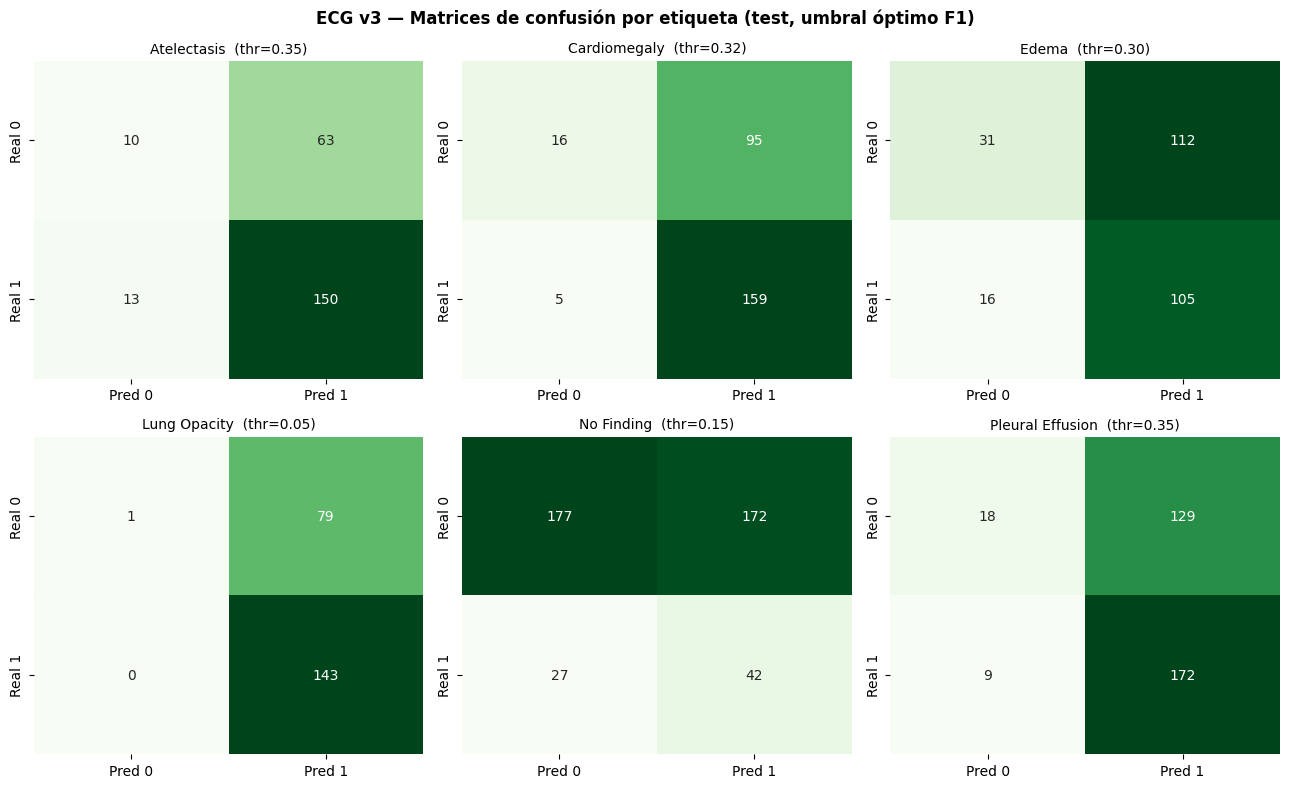

Matrices de confusión guardadas.


In [17]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 15 · MATRICES DE CONFUSIÓN POR ETIQUETA                              ║
# ╚══════════════════════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
fig.suptitle("ECG v3 — Matrices de confusión por etiqueta (test, umbral óptimo F1)", fontweight="bold")
for j, lbl in enumerate(LABELS):
    ax = axes[j//3, j%3]; sel = m_test[:, j] == 1
    yt = y_test[sel, j]; yp = (test_pred[sel, j] >= thr_val.get(lbl, 0.5)).astype(int)
    if len(yt) == 0: ax.axis("off"); continue
    cm = confusion_matrix(yt, yp, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False, ax=ax,
                xticklabels=["Pred 0","Pred 1"], yticklabels=["Real 0","Real 1"])
    ax.set_title(f"{lbl}  (thr={thr_val.get(lbl,0.5):.2f})", fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR / "confusion_matrices_v3.png", dpi=150, bbox_inches="tight"); plt.show()
print("Matrices de confusión guardadas.")


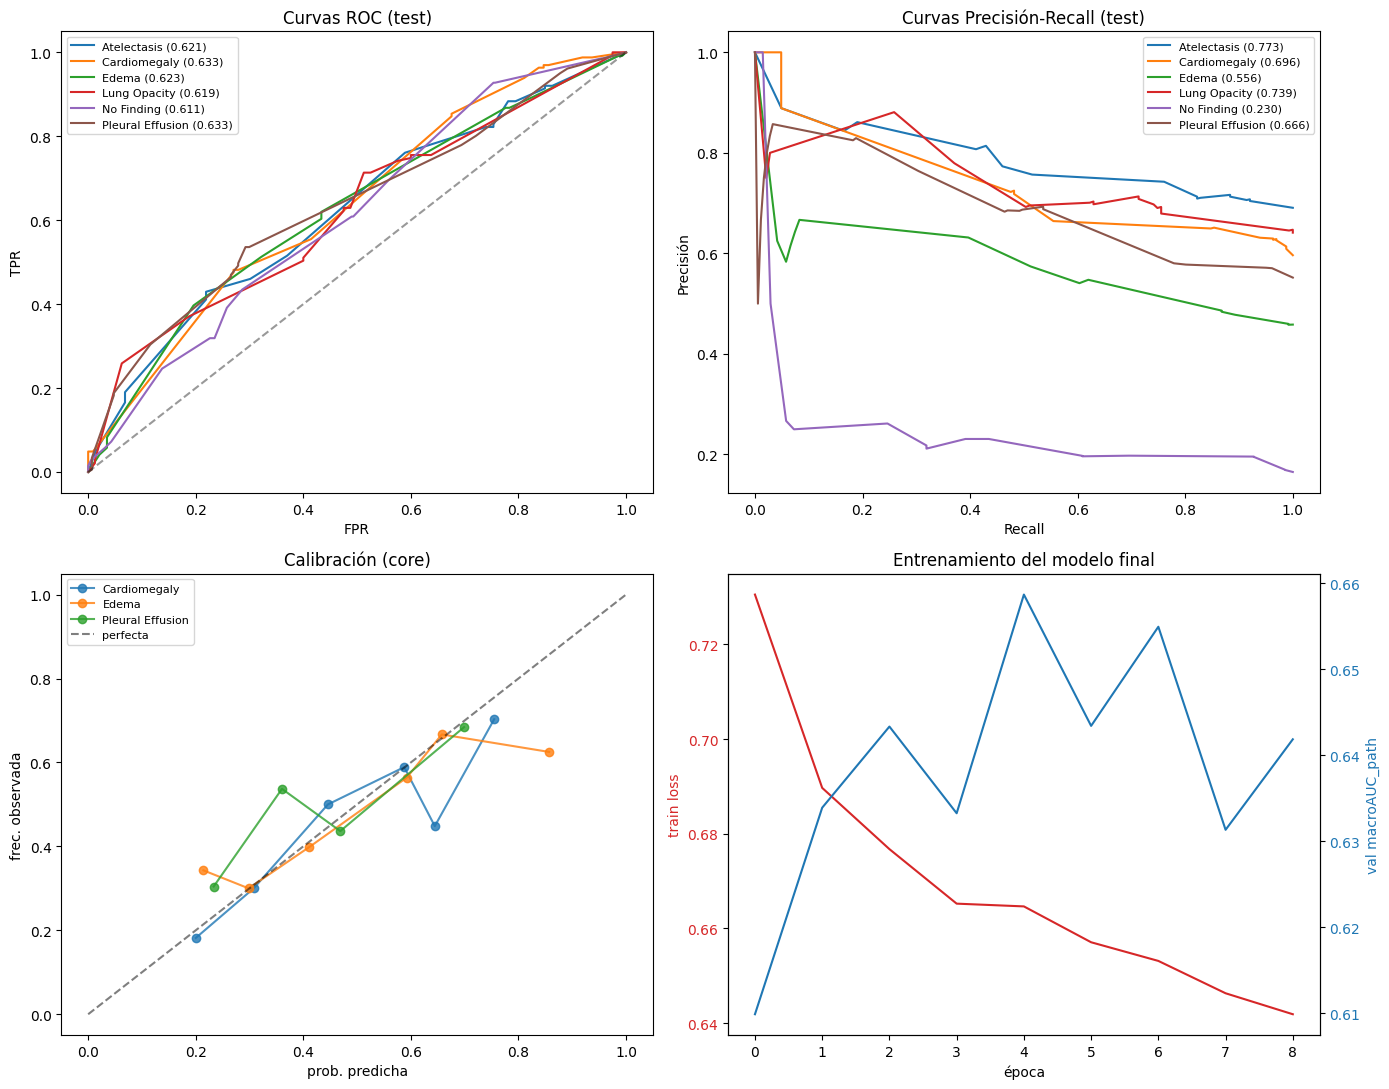

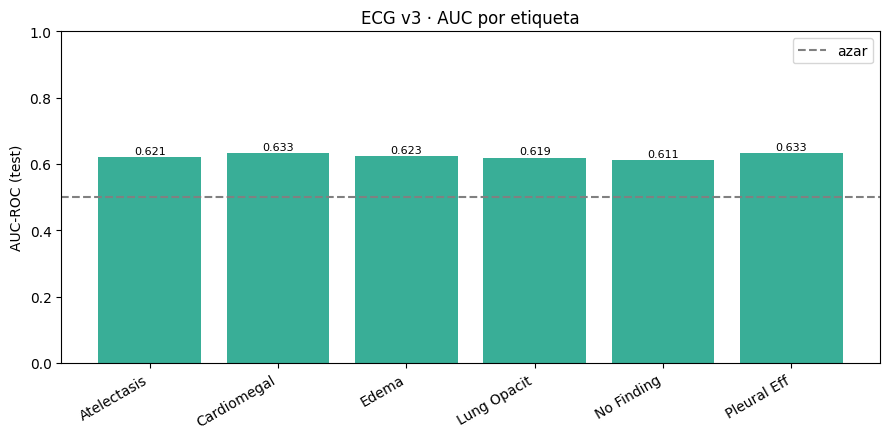

Curvas y barras guardadas en outputs_ecg_resnet1d_v3\figuras


In [18]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 16 · CURVAS ROC, PRECISIÓN-RECALL, CALIBRACIÓN Y ENTRENAMIENTO        ║
# ╚══════════════════════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
ax = axes[0, 0]
for j, lbl in enumerate(LABELS):
    sel = m_test[:, j] == 1; yt = y_test[sel, j]; yp = test_pred[sel, j]
    if len(np.unique(yt)) < 2: continue
    fpr, tpr, _ = roc_curve(yt, yp); ax.plot(fpr, tpr, label=f"{lbl} ({M[lbl]['AUC']:.3f})")
ax.plot([0,1],[0,1],"k--",alpha=0.4); ax.set_title("Curvas ROC (test)"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend(fontsize=8)
ax = axes[0, 1]
for j, lbl in enumerate(LABELS):
    sel = m_test[:, j] == 1; yt = y_test[sel, j]; yp = test_pred[sel, j]
    if len(np.unique(yt)) < 2: continue
    pr, rc, _ = precision_recall_curve(yt, yp); ax.plot(rc, pr, label=f"{lbl} ({M[lbl]['AP']:.3f})")
ax.set_title("Curvas Precisión-Recall (test)"); ax.set_xlabel("Recall"); ax.set_ylabel("Precisión"); ax.legend(fontsize=8)
ax = axes[1, 0]
for lbl in CORE_LABELS:
    j = LABELS.index(lbl); sel = m_test[:, j] == 1; yt = y_test[sel, j]; yp = test_pred[sel, j]
    bins = np.linspace(0, 1, 9); idx = np.digitize(yp, bins) - 1; xs, ys = [], []
    for b in range(len(bins)-1):
        mb = idx == b
        if mb.sum() > 5: xs.append(yp[mb].mean()); ys.append(yt[mb].mean())
    ax.plot(xs, ys, "o-", label=lbl, alpha=0.8)
ax.plot([0,1],[0,1],"k--",alpha=0.5,label="perfecta"); ax.set_title("Calibración (core)")
ax.set_xlabel("prob. predicha"); ax.set_ylabel("frec. observada"); ax.legend(fontsize=8)
ax = axes[1, 1]
ax.plot(history["train_loss"], color="tab:red", label="train loss")
ax.set_xlabel("época"); ax.set_ylabel("train loss", color="tab:red"); ax.tick_params(axis="y", labelcolor="tab:red")
ax2 = ax.twinx(); ax2.plot(history["val_auc"], color="tab:blue"); ax2.set_ylabel("val macroAUC_path", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue"); ax.set_title("Entrenamiento del modelo final")
plt.tight_layout(); plt.savefig(FIG_DIR / "curvas_v3.png", dpi=150, bbox_inches="tight"); plt.show()

fig2, ax = plt.subplots(figsize=(9, 4.5))
aucs = [M[l]["AUC"] for l in LABELS]
colors = ["#c0392b" if (np.isnan(a) or a < 0.55) else "#16a085" for a in aucs]
ax.bar(range(N_LABELS), [0 if np.isnan(a) else a for a in aucs], color=colors, alpha=0.85)
ax.axhline(0.5, color="gray", ls="--", label="azar")
ax.set_xticks(range(N_LABELS)); ax.set_xticklabels([l[:11] for l in LABELS], rotation=30, ha="right")
ax.set_ylim(0, 1); ax.set_ylabel("AUC-ROC (test)"); ax.set_title("ECG v3 · AUC por etiqueta"); ax.legend()
for i, a in enumerate(aucs):
    if not np.isnan(a): ax.text(i, a+0.01, f"{a:.3f}", ha="center", fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR / "auc_por_etiqueta_v3.png", dpi=150, bbox_inches="tight"); plt.show()
print("Curvas y barras guardadas en", FIG_DIR)


In [19]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 17 · ANÁLISIS DE EQUIDAD POR SUBGRUPO                                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝
dft = df_test.reset_index(drop=True)
for col, label in [("gender","GÉNERO"), ("race","RAZA"), ("admission_type","INGRESO")]:
    if col not in dft.columns: continue
    print(f"\n-- AUC macro (patologías) por {label} --")
    for v in sorted(dft[col].dropna().unique(), key=str):
        idx = dft.index[dft[col] == v].to_numpy()
        if len(idx) < 15: print(f"   {str(v):22s} n={len(idx):4d} (insuficiente)"); continue
        mm = multilabel_metrics(test_pred[idx], y_test[idx], m_test[idx])
        print(f"   {str(v):22s} n={len(idx):4d}  macroAUC_path={mm['macro_AUC_path']:.4f}")
print("\nAnálisis de equidad completado.")



-- AUC macro (patologías) por GÉNERO --
   0                      n= 184  macroAUC_path=0.6498
   1                      n= 280  macroAUC_path=0.6112

-- AUC macro (patologías) por RAZA --
   ASIAN                  n=  15  macroAUC_path=0.8336
   BLACK                  n=  58  macroAUC_path=0.5179
   HISPANIC_LATINO        n=  21  macroAUC_path=0.5102
   OTHER_KNOWN            n=   3 (insuficiente)
   UNKNOWN                n=  52  macroAUC_path=0.6235
   WHITE                  n= 315  macroAUC_path=0.6489

-- AUC macro (patologías) por INGRESO --
   EMERGENCY              n= 322  macroAUC_path=0.6428
   OBSERVATION            n=  66  macroAUC_path=0.5533
   SCHEDULED              n=  34  macroAUC_path=0.6321
   URGENT                 n=  42  macroAUC_path=0.5362

Análisis de equidad completado.


---
## ✅ Resumen — ECG v3 (modelo independiente)

- Señal de **12 derivaciones** (canales de la CNN 1D) submuestreada y normalizada por derivación.
- **ResNet1D compacto desde cero** · **negativos derivados por exclusividad** (No Finding) con **masking de NaN/−1 intacto**.
- `pos_weight` dinámico + BCE/focal + sampler por rareza · **Optuna** + **K-fold CV** + **modelo final** + **calibración**.
- Metadatos clínicos de 16 dims (incluye `admission_location` y `hours_adm_to_cxr`).

**Salidas:** `summary_v3.json`, `metrics_per_label_v3.csv`, `modelo_final_v3.pt`, figuras en `figuras/`
(matrices de confusión, ROC, PR, calibración, entrenamiento, AUC por etiqueta).

**Nota:** modelo **autónomo**; no exporta predicciones por muestra ni depende de ninguna fusión.

## 🔧 Palancas
`ECG_LEN`, `OPTUNA_TRIALS`, `K_FOLDS`, `FINAL_EPOCHS`, `BASE_WIDTH`, `FAST_MODE`, `DERIVE_NEGATIVES_FROM_EXCLUSIVITY`.
